# **Импорты**

In [ ]:
# Работа с массивами
import numpy as np

# Визуализация
import matplotlib.pyplot as plt

# Метрики
from sklearn.metrics import mean_squared_error

# TensorFlow / Keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Conv2DTranspose,
    MaxPooling2D,
    BatchNormalization,
    Activation
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LambdaCallback

# Датасеты
from tensorflow.keras.datasets import mnist, fashion_mnist

# **Encoder, Decoder**

In [ ]:
from tensorflow.keras.models import Model


def create_autoencoder(input_shape=(28, 28, 1)):

    # ===== Encoder =====
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2))(x)

    # ===== Decoder =====
    x = Conv2DTranspose(64, (3, 3), strides=2,
                        padding='same', activation='relu')(encoded)

    x = BatchNormalization()(x)

    x = Conv2DTranspose(32, (3, 3), strides=2,
                        padding='same', activation='relu')(x)

    outputs = Conv2D(1, (3, 3),
                     padding='same',
                     activation='sigmoid')(x)

    autoencoder = Model(inputs, outputs)

    autoencoder.compile(
        optimizer=Adam(1e-4),
        loss='mse'
    )

    return autoencoder

# **Обработка данных**

In [ ]:
# Загрузка данных
(x_train, _), (x_test, _) = mnist.load_data()
(x_fashion_train, _), (x_fashion_test, _) = fashion_mnist.load_data()

# Нормализация
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_fashion_test = x_fashion_test.astype('float32') / 255.

# Добавление размерности канала
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)
x_fashion_test = np.expand_dims(x_fashion_test, axis=-1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Обучение модели**

In [ ]:
model = create_autoencoder()

history = model.fit(
    x_train,
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0306 - val_loss: 0.0217
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0043 - val_loss: 0.0033
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0030 - val_loss: 0.0026
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0014 - val_loss: 0.0014


# **Функция оценки**

In [ ]:
def plot_images(original, reconstructed, n=5):

    plt.figure(figsize=(12, 4))

    for i in range(n):

        # Оригинал
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

        # Восстановление
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

    plt.show()

# **Предсказания модели**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


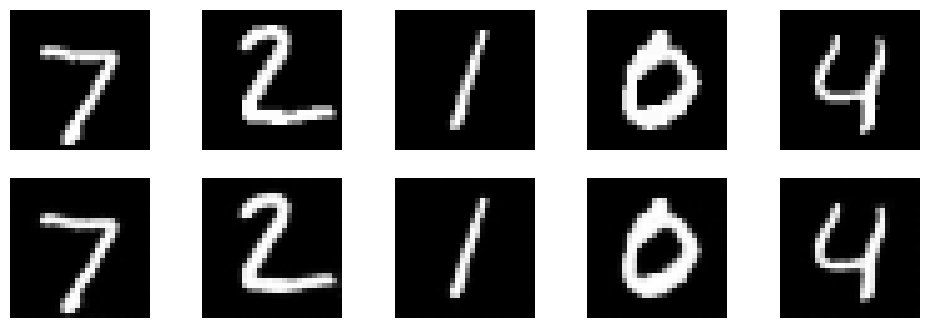

In [ ]:
pred = model.predict(x_test)

plot_images(x_test, pred)

# **Средняя ошибка**

In [ ]:
errors = []

for i in range(len(x_test)):

    mse = mean_squared_error(
        x_test[i].flatten(),
        pred[i].flatten()
    )

    errors.append(mse)

print(np.mean(errors))

0.0013692534333036746


# **Общие выводы об ошибках**

In [ ]:
fashion_pred = model.predict(x_fashion_test)

fashion_errors = []

for i in range(len(x_fashion_test)):

    mse = mean_squared_error(
        x_fashion_test[i].flatten(),
        fashion_pred[i].flatten()
    )

    fashion_errors.append(mse)

print('Ошибка цифр:', np.mean(errors))
print('Ошибка одежды:', np.mean(fashion_errors))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ошибка цифр: 0.0013692534333036746
Ошибка одежды: 0.012065360156062525


# **Обработка с учетом шума**


In [ ]:
# Добавление шума
noise_factor = 0.3

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# **Обучение модели**

In [ ]:
history = model.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0060 - val_loss: 0.0056
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0053 - val_loss: 0.0052
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0050 - val_loss: 0.0050
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 9/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0048 - val_loss: 0.0049
Epoch 10/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0048 - val_loss: 0.0049


# **Предсказания модели**

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


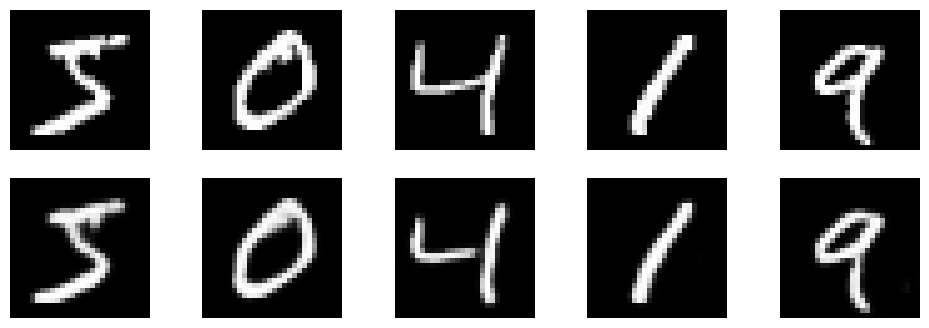

In [ ]:
decoded_imgs = model.predict(x_train_noisy)

plot_images(x_train, decoded_imgs)